In [1]:
%matplotlib inline
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re

In [2]:
l=[]
m = xr.open_rasterio(r'output/tvc136551_snowdepthavg2x2.tif').sel(band=1).drop('band')
m.name = 'PBSM3D'
m.coords['name']='PBSM3D'
l.append(m)


m = xr.open_rasterio(r'DEM_TVC_Lakes_2x2m_NAD83_UTM8N_TUPSR50DRIFT/M3_LiDAR_Processed_2m_NAD83_UTM8N_TUPSR50DRIFT_projected.tif').sel(band=1).drop('band')
m.name = 'LiDAR'
m.coords['name']='LiDAR'
l.append(m)


arr = xr.concat(l,dim='runid')

In [3]:

per_year = arr.groupby('year')

cv=per_year.std(dim='runid')/per_year.mean(dim='runid')


In [7]:
arr.to_netcdf('tvc.nc')

(553328.0, 555728.0, 7619022.0, 7621422.0)

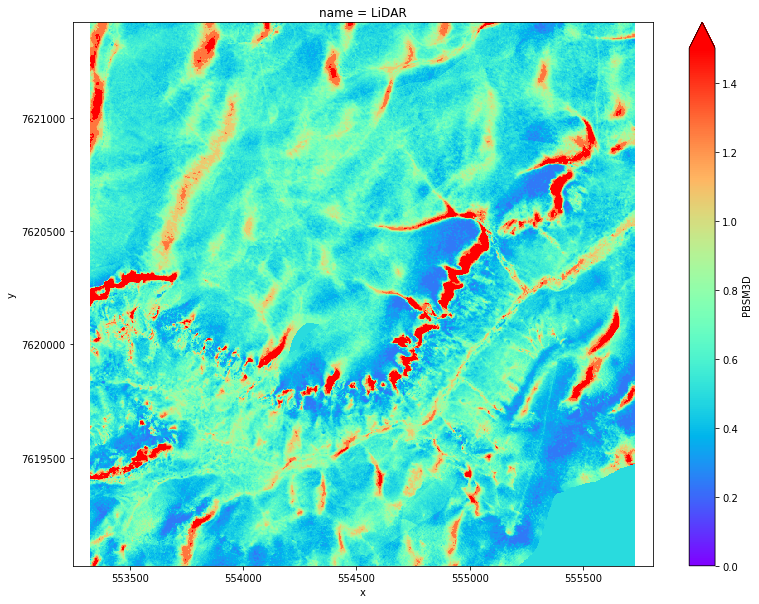

In [30]:
arr[1].plot(vmin=0, vmax=1.5,figsize=(13,10),cmap='rainbow')
plt.axis('equal')

(553328.0, 555728.0, 7619022.0, 7621422.0)

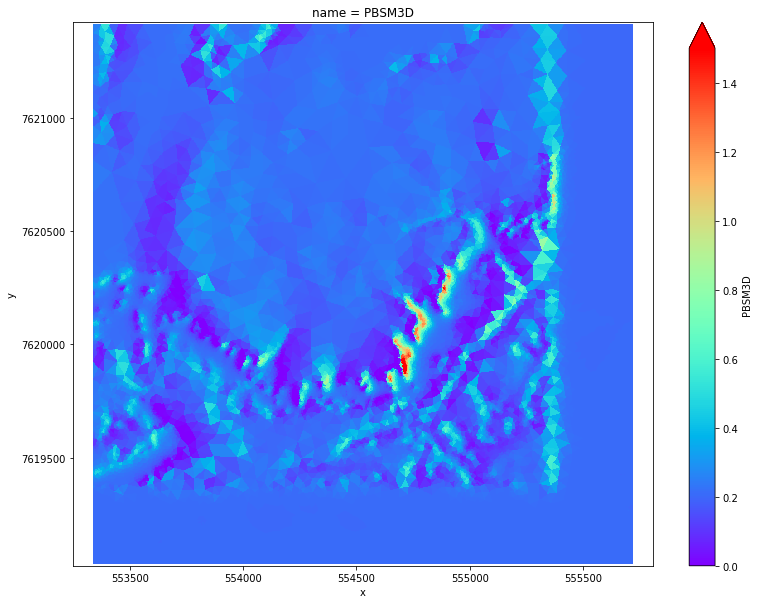

In [29]:
arr[0].plot(vmin=0, vmax=1.5,figsize=(13,10),cmap='rainbow')
plt.axis('equal')
# arr[1].plot(vmin=0, vmax=1.5,figsize=(10,10))

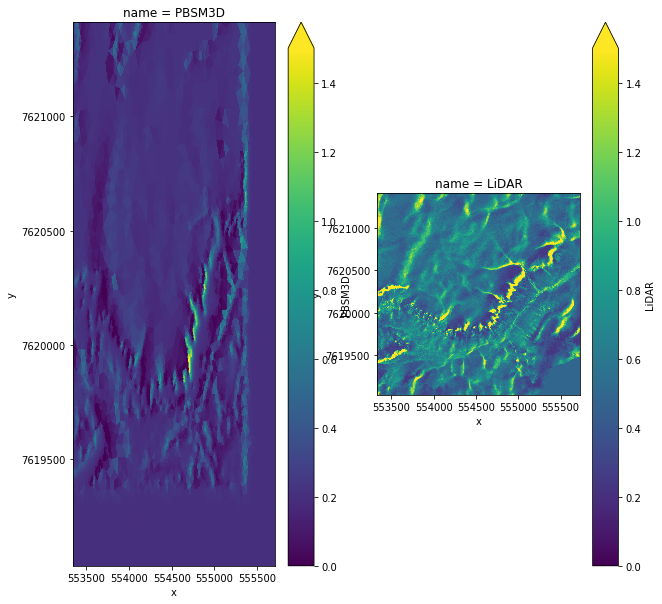

In [13]:


fig, axes = plt.subplots(nrows=1, ncols=2,figsize=(10,10))
plt.axis('scaled')
for i,ax in zip(range(0,2),axes.flat):
    l[i].plot(ax=ax,vmin=0, vmax=1.5)



In [18]:
from numpy.lib.stride_tricks import as_strided
from scipy.stats import pearsonr
z = xr.open_rasterio(r'/Users/chris/Documents/PhD/research/PBSM3D/granger/draft_v2_runs/output_2000/granger98723_W_speedup2x2.tif').sel(band=1).drop('band')\

def window(arr,shape=(3,3)):
    sub_shape = shape
    view_shape = tuple(np.subtract(arr.shape, sub_shape) + 1) + sub_shape
    arr_view = as_strided(arr, view_shape, arr.strides * 2)
    arr_view = arr_view.reshape((-1,) + sub_shape)
    return(arr_view)

In [21]:
model= window(arr[0].values,(25,25))
obs = window(arr[1].values,(25,25))

print(model.size)
print(obs.size)

864360000
864360000


/usr/local/lib/python3.6/site-packages/scipy/stats/stats.py:3003: RuntimeWarning: invalid value encountered in double_scalars
  r = r_num / r_den


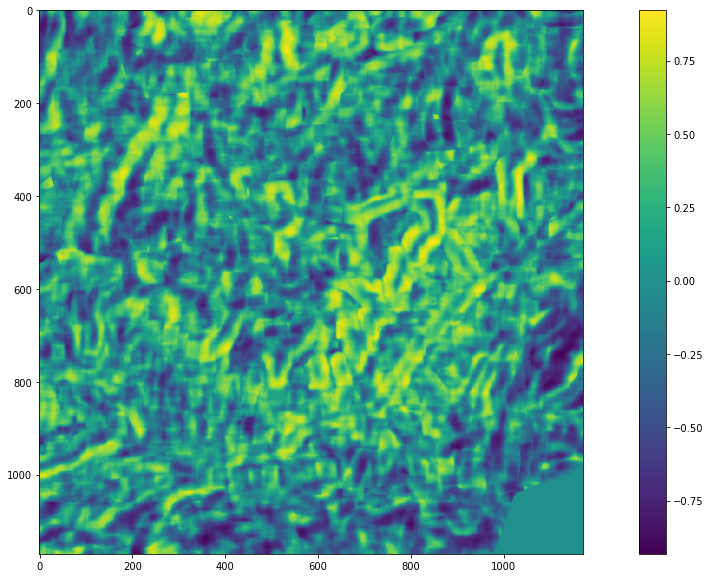

In [4]:
from numpy.lib.stride_tricks import as_strided
from scipy.stats import pearsonr
sub_shape = (30,30)
view_shape = tuple(np.subtract(arr[0].values.shape, sub_shape) + 1) + sub_shape
arr_view = as_strided(arr[0].values, view_shape, arr[0].values.strides * 2)
arr_view = arr_view.reshape((-1,) + sub_shape)

view_shape = tuple(np.subtract(arr[1].values.shape, sub_shape) + 1) + sub_shape
arr_view_obs = as_strided(arr[1].values, view_shape, arr[1].values.strides * 2)
arr_view_obs = arr_view_obs.reshape((-1,) + sub_shape)
    
out=[]
for zz,ccvv in zip(arr_view_obs,arr_view):
    nas = np.logical_or(np.isnan(zz), np.isnan(ccvv))
    pr = pearsonr(zz[~nas].flatten(),ccvv[~nas].flatten())[0]
    out.append(pr)
   
a=np.array(out)
a[np.isnan(a)]=0
ns = np.ceil(np.sqrt(len(a))).astype(int)
s = np.zeros(ns**2)
s[:a.size] = a
s = s.reshape(ns,ns)
plt.figure(figsize = (20,10))
plt.imshow(np.flipud(s))
plt.colorbar()